In [ ]:
# Q4 Using the Monte Carlo Method, determine the area of the region

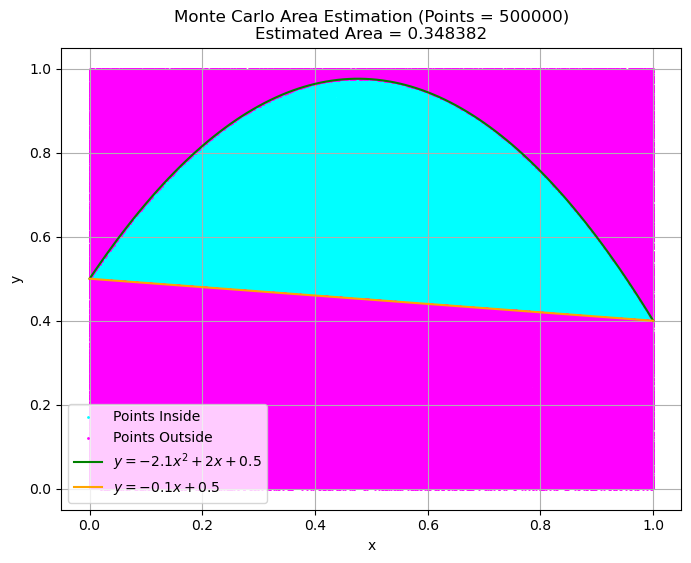

The estimated area of the region is: 0.348382


In [ ]:
import random
import matplotlib.pyplot as plt

# ---------------------------------------------------
#  Define the upper and lower curves of the region
# ---------------------------------------------------
def upper_curve(x):
    """
    Returns the y-value of the upper boundary for a given x.
    Equation: y = -2.1*x^2 + 2*x + 0.5
    """
    return -2.1 * x**2 + 2 * x + 0.5

def lower_curve(x):
    """
    Returns the y-value of the lower boundary for a given x.
    Equation: y = -0.1*x + 0.5
    """
    return -0.1 * x + 0.5

# ---------------------------------------------------
#  Monte Carlo function to estimate area
# ---------------------------------------------------
def estimate_area_monte_carlo(total_points):
    """
    Estimates the area between the upper_curve and lower_curve
    using the Monte Carlo method with `total_points` random samples.
    """
    # Counters for points inside the region
    count_inside = 0
    
    # Lists to store points for plotting
    x_inside = []   # x-coordinates of points inside the region
    y_inside = []   # y-coordinates of points inside the region
    x_outside = []  # x-coordinates of points outside
    y_outside = []  # y-coordinates of points outside

    # Define bounding rectangle that encloses the region
    x_start, x_end = 0, 1
    y_start, y_end = 0, 1
    bounding_area = (x_end - x_start) * (y_end - y_start)  # Area of rectangle

    # ---------------------------------------------------
    # 2a. Randomly generate points and check if they lie in the region
    # ---------------------------------------------------
    for _ in range(total_points):
        # Generate a random x and y coordinate within the bounding rectangle
        rand_x = random.uniform(x_start, x_end)
        rand_y = random.uniform(y_start, y_end)

        # Check if the point is inside the area between upper and lower curves
        if lower_curve(rand_x) <= rand_y <= upper_curve(rand_x):
            count_inside += 1              # Increment inside counter
            x_inside.append(rand_x)        # Store for plotting
            y_inside.append(rand_y)
        else:
            x_outside.append(rand_x)       # Store points outside for plotting
            y_outside.append(rand_y)

    # ---------------------------------------------------
    # 2b. Estimate the area
    # ---------------------------------------------------
    # Fraction of points inside the region × total bounding rectangle area
    area_estimate = bounding_area * (count_inside / total_points)

    # ---------------------------------------------------
    #  Plot the points and curves for visualization
    # ---------------------------------------------------
    plt.figure(figsize=(8, 6))

    # Plot points inside the region (cyan)
    plt.scatter(x_inside, y_inside, color='cyan', s=1, label='Points Inside')

    # Plot points outside the region (magenta)
    plt.scatter(x_outside, y_outside, color='magenta', s=1, label='Points Outside')
    
    # Plot the upper and lower curves
    x_vals = [i / 100 for i in range(101)]  # 101 points from 0 to 1
    plt.plot(x_vals, [upper_curve(x) for x in x_vals], color='green', label='$y = -2.1x^2 + 2x + 0.5$')
    plt.plot(x_vals, [lower_curve(x) for x in x_vals], color='orange', label='$y = -0.1x + 0.5$')
    
    # Add title, labels, legend, and grid
    plt.title(f'Monte Carlo Area Estimation (Points = {total_points})\nEstimated Area = {area_estimate:.6f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Return the estimated area
    return area_estimate

# ---------------------------------------------------
# 4️⃣ Run the Monte Carlo simulation
# ---------------------------------------------------
if __name__ == '__main__':
    total_points = 500_000             # Number of random points to generate
    area = estimate_area_monte_carlo(total_points)  # Estimate the area
    
    print(f"The estimated area of the region is: {area:.6f}")
